In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
USE_CACHED_MODEL = True

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap, BoundaryNorm
import os
import seaborn as sns
import sklearn.metrics
import torch
import numpy as np

import cebra
from cebra.integrations.plotly import plot_embedding_interactive
from plotly.subplots import make_subplots

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the datasets
hippocampus_a = cebra.datasets.init('rat-hippocampus-single-achilles')
hippocampus_b = cebra.datasets.init('rat-hippocampus-single-buddy')
hippocampus_c = cebra.datasets.init('rat-hippocampus-single-cicero')
hippocampus_g = cebra.datasets.init('rat-hippocampus-single-gatsby')

datasets = [hippocampus_a, hippocampus_b, hippocampus_c, hippocampus_g]

# Download the cached model
if USE_CACHED_MODEL:
    print("Downloading cached model. If you want to re-run, set USE_CACHED_MODEL to False.")
    import os, requests, zipfile, shutil
    model_path = os.path.join("model", "250609-unified-reference-run.pt")
    if not os.path.exists(model_path):
        url = "https://figshare.com/ndownloader/articles/29275358?private_link=ae8099185f5e2f5e8185"
        with open("data.tgz", "wb") as f: f.write(requests.get(url).content)
        with zipfile.ZipFile("data.tgz", "r") as zip_ref: zip_ref.extractall()
        os.makedirs("model", exist_ok=True)
        shutil.move("250609-unified-reference-run.pt", "model")
        if os.path.exists("data.tgz"): os.remove("data.tgz")

/usr/local/lib/python3.10/dist-packages/cebra/__init__.py:118: UserWarning: Your code triggered a lazy import of cebra.datasets. While this will (likely) work, it is recommended to add an explicit import statement to you code instead. To disable this warning, you can run ``cebra.allow_lazy_imports()``.
  warnings.warn(


In [3]:
# Split data and labels (labels we use later!)
train_data, valid_data = [], []
train_continuous_label, valid_continuous_label = [], []
for i, dataset in enumerate(datasets):
    split_idx = int(0.8 * len(dataset.neural)) #suggest: 5%-20% depending on your dataset size

    train_data.append(dataset.neural[:split_idx])
    valid_data.append(dataset.neural[split_idx:])

    train_continuous_label.append(dataset.continuous_index.numpy()[:split_idx])
    valid_continuous_label.append(dataset.continuous_index.numpy()[split_idx:])

train_datasets = [
    cebra.data.TensorDataset(
        neural=train_data[i], continuous=train_continuous_label[i], device=device
    )
    for i in range(len(train_data))
]

valid_datasets = [
    cebra.data.TensorDataset(valid_data[i], continuous=valid_continuous_label[i], device=device)
    for i in range(len(valid_data))
]


In [4]:
# Hyperparameters:
config = {"model_architecture": "offset10-model",
    "batch_size": 2048,
    "output_dimension": 32,
    "time_offsets": 10,
    "learning_rate": 0.0003,
    "num_hidden_units": 32,
    "temperature": 1,
    "max_iterations": 5000,
    "conditional": "time_delta",
    "verbose": True,
}

In [5]:
# Number of neurons = sum of neurons in all datasets
num_neurons = 0
for dataset in train_datasets:
    num_neurons += dataset.neural.shape[1]

# Define the dataset
dataset = cebra.data.UnifiedDataset(dataset for dataset in train_datasets)

# Set the masks for the dataset
# 'RandomNeuronMask' and 'RandomTimestepMask' are used to randomly mask neurons and timesteps
# during training, which helps the model to learn better representations.
dataset.set_masks({"RandomNeuronMask": (0.3, 0.9, 0.05),
                   "RandomTimestepMask": (0.3, 0.9, 0.05)})

dataset.to(device)

# Define the dataset loader
loader = cebra.data.UnifiedLoader(
    dataset,
    conditional=config["conditional"],
    num_steps=config["max_iterations"],
    batch_size=config["batch_size"],
    time_offset=config["time_offsets"],
)

dataset.to(device)

# Define the model
model = cebra.models.init(
    config["model_architecture"],
    num_neurons=num_neurons,
    num_units=config["num_hidden_units"],
    num_output=config["output_dimension"],
)
model.to(device)
dataset.configure_for(model)

criterion = cebra.models.FixedCosineInfoNCE(temperature=config["temperature"])
criterion.to(device)
optimizer = torch.optim.Adam(list(model.parameters()), lr=config["learning_rate"])

# Define the solver
solver = cebra.solver.UnifiedSolver(
    model=model, criterion=criterion, optimizer=optimizer, tqdm_on=config["verbose"]
)

In [6]:
if os.path.exists("model/250609-unified-reference-run.pt"):
    checkpoint = torch.load('model/250609-unified-reference-run.pt', map_location=device, weights_only = False)
    solver.load_state_dict(checkpoint, strict=True)
else:
    solver.fit(loader)
    solver.save(logdir = "model", filename = "250609-unified-reference-run.pt")

In [7]:
import cebra_lens as lens

In [8]:
model_path  = "model"

groups = {'250609-unified-reference-run.pt':'unified_model',}

In [9]:
import pathlib
models_folder_path = pathlib.Path("model")

models = {}
for file in models_folder_path.iterdir():
    if str(file).endswith((".pt", ".pth")):
        # loaded_model = cebra.CEBRA.load(
        #     file, backend=backend, map_location=torch.device("cpu")
        # ).to("cpu")
        checkpoint = torch.load(file, map_location=device, weights_only = False)
        solver.load_state_dict(checkpoint, strict=True)
        key = groups.get(file.stem, file.stem)
        models.setdefault(key, []).append(solver)
        print(f"Model {file.stem} loaded successfully.")

Model 250609-unified-reference-run loaded successfully.


In [10]:
from tqdm import tqdm
import torch.nn as nn

dataset_label = None
layer_type = nn.Conv1d
session_id = 0

In [11]:
decoding_models = lens.Decoding(train_data, train_continuous_label, 
                                valid_data, valid_continuous_label, 
                                session_id=session_id, 
                                layer_type=layer_type)

In [12]:
activations_valid, labels_dict = lens.get_activations_model(
                model=solver,
                data=valid_data,
                labels=valid_continuous_label,
                activations_keys_prefix=model.__class__.__name__,
                session_id=0,
                layer_type=nn.Conv1d,
            )

cut_indices: [(4, -4), (3, -3), (2, -2), (1, -1), (0, 0), (0, 0)]


In [13]:
results_dict = lens.compute_metric(models, decoding_models, output_only=False)

Processing 250609-unified-reference-run:   0%|          | 0/1 [00:00<?, ?it/s]

cut_indices: [(4, -4), (3, -3), (2, -2), (1, -1), (0, 0), (0, 0)]
cut_indices: [(4, -4), (3, -3), (2, -2), (1, -1), (0, 0), (0, 0)]
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)


Processing 250609-unified-reference-run: 100%|██████████| 1/1 [00:03<00:00,  3.07s/it]

coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
coucou (1012,) (1012,) (1012, 32)
The decoding analysis initialized with the following parameters:
Session ID: 0
Dataset label: None
Layer type: <class 'torch.nn.modules.conv.Conv1d'>
If you want to change the parameters, please re-initialize the class with the new parameters  or if you want to change the output_only parameter, call the compute_metric function with the  output_only parameter set to True or False.


In [14]:
results_dict = lens.compute_metric(models, decoding_models, output_only=True)

Processing 250609-unified-reference-run:   0%|          | 0/1 [00:00<?, ?it/s]

coucou (2036,) (2036,) torch.Size([2036, 32])
coucou (2036,) (2036,) torch.Size([2036, 32])


Processing 250609-unified-reference-run: 100%|██████████| 1/1 [00:04<00:00,  4.76s/it]

coucou (2036,) (2036,) torch.Size([2036, 32])
The decoding analysis initialized with the following parameters:
Session ID: 0
Dataset label: None
Layer type: <class 'torch.nn.modules.conv.Conv1d'>
If you want to change the parameters, please re-initialize the class with the new parameters  or if you want to change the output_only parameter, call the compute_metric function with the  output_only parameter set to True or False.


In [15]:
lens.utils_plot.style()

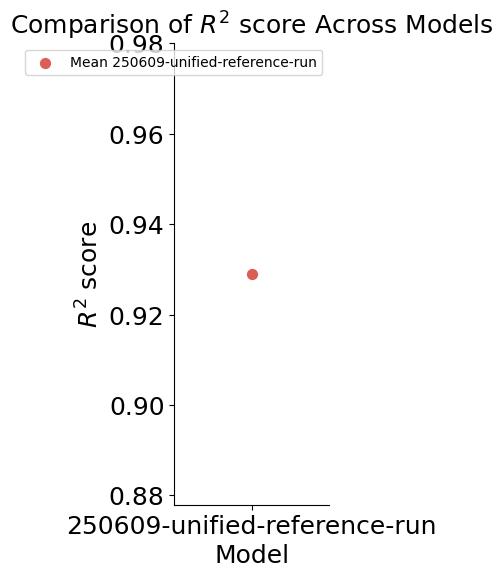

In [16]:
fig = lens.plot_metric(results_dict, decoding_models, label = 0, plot_error = False)

In [17]:
activations_dict, labels_dict = lens.get_activations(
    models=models,
    data=train_data,
    labels=train_continuous_label,
    session_id=0,
)

cut_indices: [(4, -4), (3, -3), (2, -2), (1, -1), (0, 0), (0, 0)]


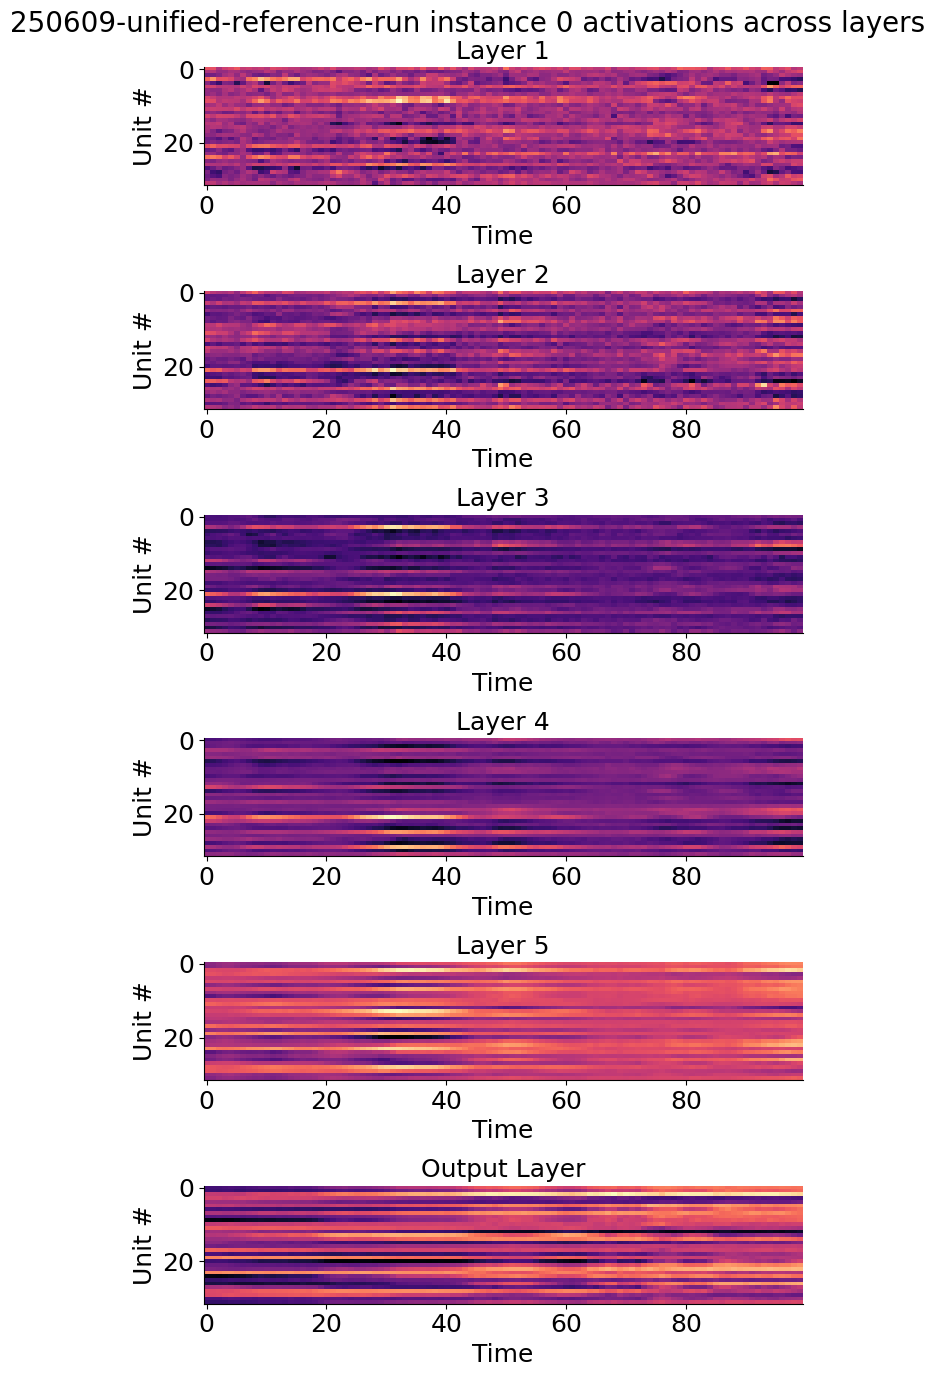

In [18]:
fig = lens.plot_activations(
    activations_dict,
    plot_title="Multi Trained",
    figsize=(7, 14),
)

In [19]:
"""fig = lens.plot_embeddings(
    activations_dict,
    labels=train_continuous_label[0][:,0],
    dataset_label=dataset_label,
    markersize=5,
    idx_order=(12, 31, 8))"""

'fig = lens.plot_embeddings(\n    activations_dict,\n    labels=train_continuous_label[0][:,0],\n    dataset_label=dataset_label,\n    markersize=5,\n    idx_order=(12, 31, 8))'

In [20]:
model1 = activations_dict["250609-unified-reference-run"][0]
model2 = activations_dict["250609-unified-reference-run"][0]

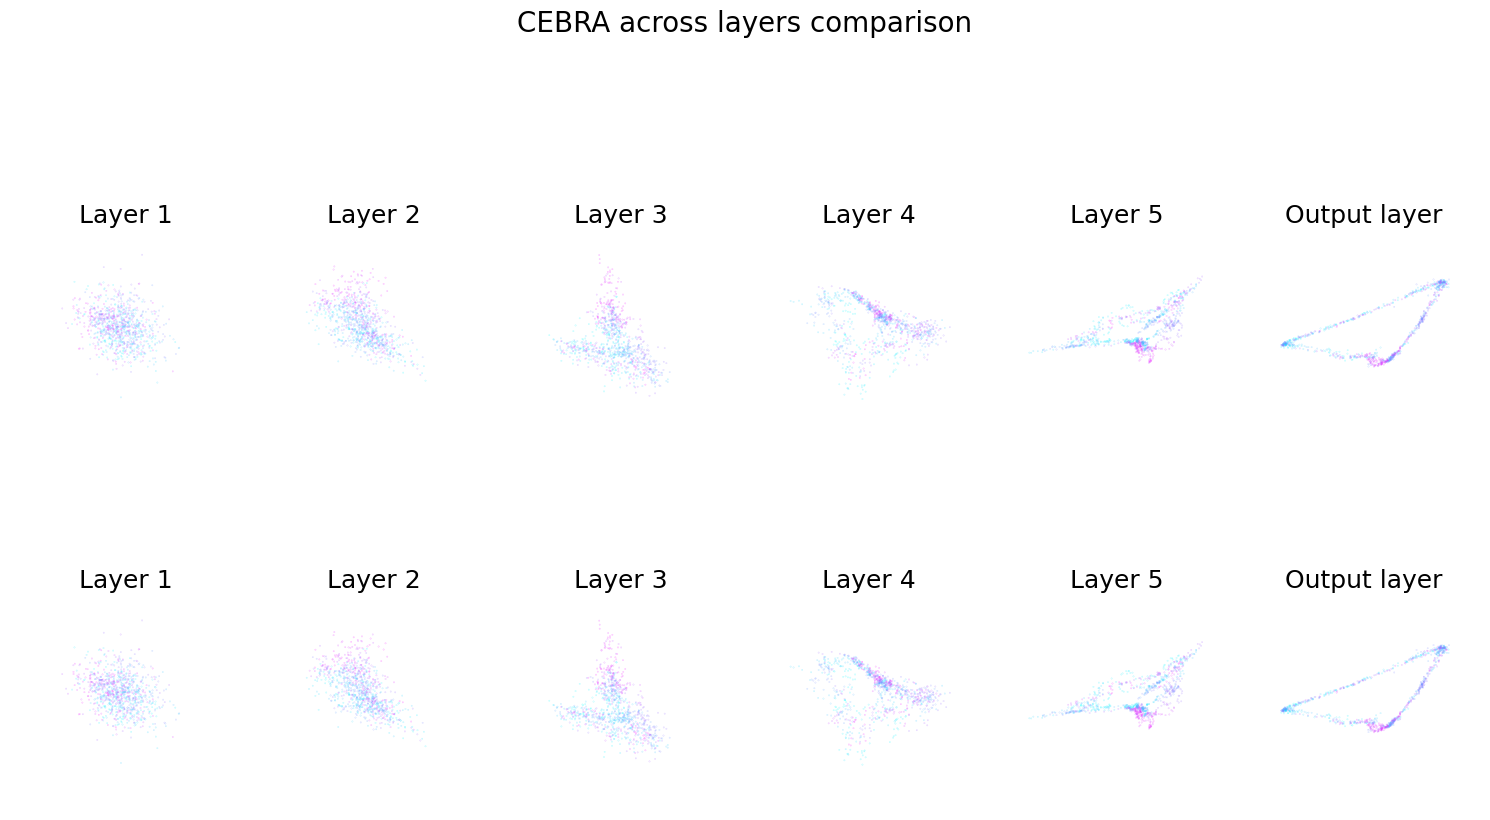

In [21]:
fig = lens.compare_embeddings_layers(
    embeddings_1=model1, 
    embeddings_2=model2,
    labels= train_continuous_label[0][:,0],
    comparison_groups=("CEBRA embeddings", ["Single", "Multi"]))

In [22]:
num_samples_tSNE = 2000

In [23]:
tsne_model = lens.Tsne(num_samples_tSNE)

In [24]:
#tSNE_dict = lens.compute_metric(activations_dict, tsne_model)

In [25]:
#fig = lens.plot_metric(tSNE_dict, tsne_model, 
#                       labels=train_continuous_label[0][:,0], alpha=1, markersize=2, sample_plot = 900)

In [26]:
comparisons = [
        ("250609-unified-reference-run", "250609-unified-reference-run"),
    ]

In [27]:
cka_multi = lens.CKA(comparisons)
cka_matrices = lens.compute_metric(activations_dict, cka_multi)

100%|██████████| 1/1 [00:00<00:00,  4.79it/s]


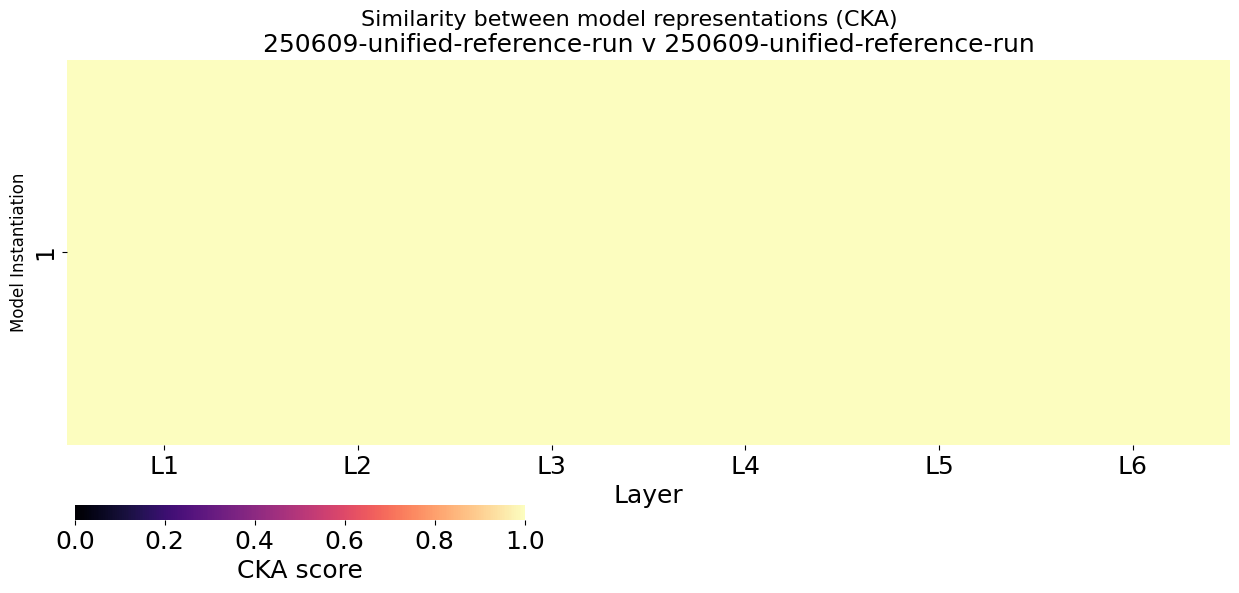

In [28]:
fig = lens.plot_metric(cka_matrices, cka_multi, annot=False)

In [29]:
activations_dict, labels_dict = lens.get_activations(
    models=models,
    data=train_data,
    labels=train_continuous_label,
    session_id=0,
)

cut_indices: [(4, -4), (3, -3), (2, -2), (1, -1), (0, 0), (0, 0)]


In [32]:
#if you put is_discrete_labels = False then you'll get a warning and an erro (division by zero bcs 0.005 * len(data <1))
#to make it work for now put for example 0.5 in the misc.py file--> to discuss 
rdm_single = lens.RDM(
    data=train_data,
    label=train_continuous_label[0][:, 0],
    is_discrete_labels = True,
    metric="cosine",
)

In [33]:
multi_rdm_corr = lens.compute_metric(activations_dict, rdm_single, labels=labels_dict, bool_oracle=False)

Processing 250609-unified-reference-run: 100%|██████████| 1/1 [00:00<00:00, 2068.20it/s]

RDM class initialized with the following parameters:
The dataset label is not specified,
 this label has been noted DISCRETE = True.
If this is not the desired behavior, please check the parameters passed to the RDM class.
